In [33]:
import numpy as np
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [38]:
# -----------------------------
# KNN Implementation from Scratch
# -----------------------------
class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def predict(self, X_test):
        predictions = [self._predict(x) for x in X_test]
        return np.array(predictions)

    def _predict(self, x):
        # Compute distances to all training points
        distances = [np.linalg.norm(x - x_train) for x_train in self.X_train]
        
        # Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        
        # Get corresponding labels
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

In [35]:
# -----------------------------
# Load Data
# -----------------------------
iris = load_iris()
X, y = iris.data, iris.target

In [39]:
# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [48]:
# -----------------------------
# Evaluate for different k
# -----------------------------
k_values = [1, 3, 5, 7, 9, 11, 15]
accuracies = []

In [49]:
for k in k_values:
    clf = KNN(k=k)
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    accuracy = np.mean(predictions == y_test)
    accuracies.append(accuracy)
    print(f"k = {k}, Accuracy = {accuracy:.4f}")


k = 1, Accuracy = 1.0000
k = 3, Accuracy = 1.0000
k = 5, Accuracy = 1.0000
k = 7, Accuracy = 0.9667
k = 9, Accuracy = 1.0000
k = 11, Accuracy = 1.0000
k = 15, Accuracy = 1.0000


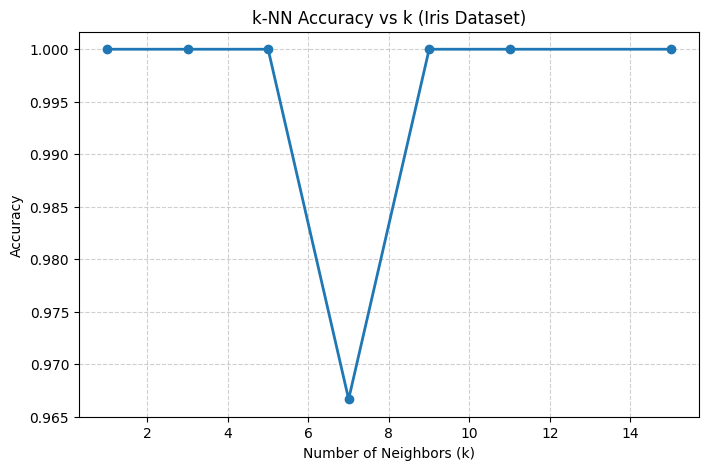

In [50]:
# -----------------------------
# Plot Accuracy vs k
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='-', linewidth=2)
plt.title("k-NN Accuracy vs k (Iris Dataset)")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()